Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
速度定数がすべて既知で、初期濃度を与えた場合、各化学種の経時変化をシミュレーションする場合の事例  
1. csvに書き込んだ反応式を読み込む。ただし速度定数はすべて既知とする  
2. RxnIVPsolv("sample_data.csv")でインスタンス化し、化学種ごとの微分型の反応速度式を作成する  
3. 作成した微分方程式を、数値解析可能な形式にする  
4. 化学種ごとの濃度の経時変化を求める。数値積分では、get_ode_system()で必要なオブジェクトを取得する。   
5. matplotlibで結果をプロットし、経時変化を図示する  

## 引用文献  
1) 桜田一郎; 坂口康義; 大村恭弘. [11] 数種の水溶性高分子酢酸エステルの加水分解速度. 高分子化學, 1970, 27.297: 89-96.  https://doi.org/10.1295/koron1944.27.89  

文献中 Table 7の数値を使用した。  

## 反応式を記載したcsvファイルを指定する  

In [2]:
file_path = './sample_data/sample_rxn_ref1.csv'  # CSVファイルのパスを指定

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [3]:
import numpy as np

from rxnfit import RxnODEbuild, SolverConfig, RxnODEsolver


In [4]:
builded_rxnode = RxnODEbuild(file_path)

In [5]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 8
unique species: ['AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
rate constant: {'k1': 0.054, 'k2': 0.044, 'k3': 0.031}

=== debug info ===
Successfully created function for AcOEt with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for OHa1 with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for AcOa1 with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for EtOH with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for AcOiPr with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for iPrOH with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for EGOAc2 with args: ['t', 'AcOE

In [6]:
builded_rxnode.rate_consts_dict

{'k1': 0.054, 'k2': 0.044, 'k3': 0.031}

## 数値積分を実行する  

In [7]:
# 各化学種の初期濃度の入力順序を確認する  
builded_rxnode.get_ode_info()

number of species: 8
unique species: ['AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
rate constant: {'k1': 0.054, 'k2': 0.044, 'k3': 0.031}


In [ ]:
# get_ode_infoの出力を参照して、初期値等の入力項目を渡す
config = SolverConfig(
    y0 = [1.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], # 初期濃度（必須）
    t_span=(0, 30),         # 時間範囲（必須）
    # t_eval: Optional[np.ndarray] = field(default=None),  # 任意
    method = "RK45",  # 任意
    rtol = 1e-6,    # 任意    
)

In [9]:
# 基本的な数値積分 -インスタンス化-
solved_rxnode = RxnODEsolver(builded_rxnode, config)

In [10]:
ode_construct, sol = solved_rxnode.solve_system()

Successfully created function for AcOEt with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for OHa1 with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for AcOa1 with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for EtOH with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for AcOiPr with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for iPrOH with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for EGOAc2 with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', 'EG']
Successfully created function for EG with args: ['t', 'AcOEt', 'OHa1', 'AcOa1', 'EtOH', 'AcOiPr', 'iPrOH', 'EGOAc2', '

/home/mt_oh/work/rxnfit/examples/../src/rxnfit/solv_ode.py:205: UserWarning: Though the import numbalsoda succeeded, RHS is not supported.
  solution = solve_ode(



=== Time-course plot ===


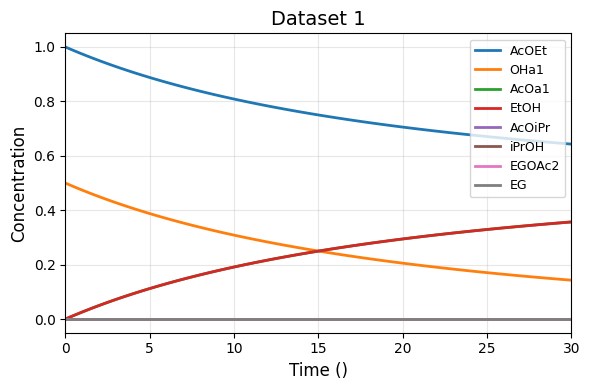


=== Concentration at the final time point ===
Dataset 1:
  AcOEt: 0.643029
  OHa1: 0.143029
  AcOa1: 0.356971
  EtOH: 0.356971
  AcOiPr: 0.000000
  iPrOH: 0.000000
  EGOAc2: 0.000000
  EG: 0.000000


In [11]:
solved_rxnode.solution_plot()